# Extending to a d-p model: Charge-transfer physics and double-counting

In this tutorial, we will extend our model of La$_{2}$CuO$_{4}$ beyond the single-band approximation by explicilty including the in-plane $2p_{x}$ and $2p_{y}$ orbitals from the oxygen, resulting in a three orbital $d$-$p$ model. This richer low-energy model allows us to captures essential aspects of **charge-transfer physics**, which plays a central role in the electronic structure of cuprate superconductors.

We will learn how to:
- Modify the embedding description (``Embedding``) to separate the Cu-$d_{x^{2}-y^{2}}$ from the oxygen and only solve the Cu-$d$ impurity.
- Introduce the **double-counting correction** to maintain the relative energy splitting between the Cu-$3d$ and O-$2p$ levels.
- Solve the impurity problem within DMFT and analyze how the spectral weight is distributed between the $d$ and $p$ orbitals.
- Investigate the effects of electronic **screening** and study the size of the **charge-transfer gap** in our model.

By the end of this tutorial, you will understand how to move beyond the single-band Hubbard model, handle double-counting corrections carefully, and analyze how the inclusion of ligand states qualitatively changes the low-energy electronic structure of correlated materials like La$_{2}$CuO$_{4}$.

## The d-p model

Our goal is to repreoduce the results in X and Y. In these papers, a $d$-$p$ model is studied for La$_{2}$CuO$_{4}$. It is determined that the $d$-$p$ interactions are crucial to capturing the correct charge-transfer physics. Thus, we will solve the following model:

$$ H = H_{0} + H_{\mathrm{int}}, $$
where $H_{0}$ is the tight-binding Hamiltonian and $H_{\mathrm{int}}$ corresponds to

$$ H_{\mathrm{int}} = U_{dd} \sum_{i}n_{i\uparrow}n_{i\downarrow} + U_{pp}\sum_{j}n_{jp\uparrow}n_{jp\downarrow} + U_{pd}\sum_{\langle ij \rangle}n_{id}n_{jp},$$
where $n= n_{\uparrow} + n_{\downarrow}$. We will solve the $d$-$d$ interactions within DMFT using a CT-QMC solver, while the $p$-$p$ and $p$-$d$ interactions will be solved at the Hartree level.

$$ \begin{pmatrix} \Sigma_{dd} & &\\ & \Sigma_{pp} & \\ & & \Sigma_{pp} \end{pmatrix},$$
where $$ \begin{align} \Sigma_{dd} &= \Sigma_{\mathrm{imp}} - U_{dd}(n_{d} - \frac{1}{2}) + 4U_{pd}(n_{p} - n_{p}^{\mathrm{DFT}})\\
\Sigma_{pp} &= U_{pp}(n_{p}-n_{p}^{\mathrm{DFT}}) + 2U_{pd}(n_{d}-n_{d}^{\mathrm{DFT}}) \end{align}$$

In [2]:
import triqs_modest as modest
from triqs.gf import MeshImFreq

target_density = 5.0
shells = [modest.AtomicShellT(dim=1, l=2, dft_idx=0, cls_idx=0),
          modest.AtomicShellT(dim=1, l=2, dft_idx=0, cls_idx=1),
          modest.AtomicShellT(dim=1, l=2, dft_idx=0, cls_idx=2)]
          
obe = modest.one_body_elements_from_wannier90('./emery/lco', "NonPolarized", shells)
print(obe)


beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

mu = modest.find_chemical_potential(target_density, obe, mesh, modest.BzIntOptions(), verbosity=True)

triqs_modest.module.OneBodyElementsTb [wrapped from C++ object triqs::modest::one_body_elements_tb]


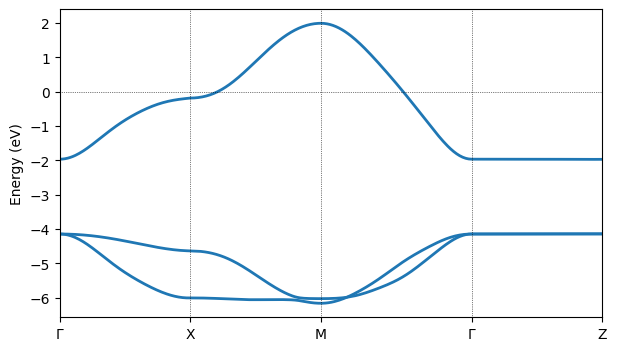

In [3]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path
from utils.mpl_interface import *

# create high-symmetry path
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments)

e_k = obe.H[0].eigenvalues(k_points).T
plt.figure(figsize=(7,4))
for band in e_k: plt.plot(k_lin, band-mu, '-', color='C0', lw=2)
plt.ylabel('Energy (eV)')
for k in k_ticks: plt.axvline(k, color='k', ls='dotted',lw=0.5)
plt.axhline(0, color='k', ls='dotted', lw=0.5)
plt.xticks(k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'])
plt.xlim(min(k_ticks), max(k_ticks))
plt.show()

In [4]:
E = modest.make_embedding_with_equivalences(obe.C_space)
print(E)

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1   1   1
        α:   0   1   2

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
      [n_imp = 1] dim_γ =   1
                      γ =   0
      [n_imp = 2] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]
      [imp_idx = 1] up_0 [1], down_0 [1]
      [imp_idx = 2] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  
      α = 1  |   (imp_idx = 1, γ = 0, τ = 0)    (imp_idx = 1, γ = 0, τ = 1)  
      α = 2  |   (imp_idx = 2, γ = 0, τ = 0)    (imp_idx = 2, γ = 0, τ = 1)  



In [5]:
gloc_C = modest.gloc(mesh, obe, mu, modest.BzIntOptions())

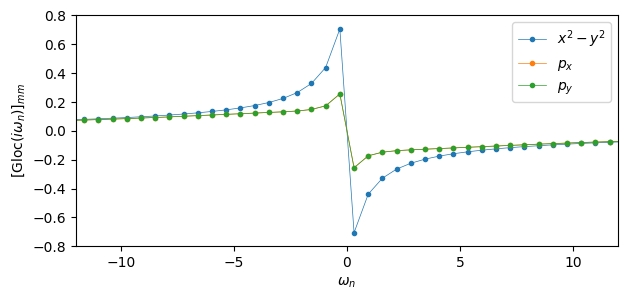

In [8]:
from triqs.plot.mpl_interface import oplot

fig, ax = plt.subplots(figsize=(7,3))
ax.oplot(gloc_C['0', 'up'][0,0].imag, 'o-', ms=3, lw=0.5, label=r'$x^{2}-y^{2}$')
ax.oplot(gloc_C['0', 'up'][1,1].imag, 'o-', ms=3, lw=0.5, label=r'$p_{x}$')
ax.oplot(gloc_C['0', 'up'][2,2].imag, 'o-', ms=3, lw=0.5, label=r'$p_{y}$')
ax.set_ylabel(r'[Gloc($i\omega_{n}$)]$_{mm}$')
ax.set_xlim(-12, 12); ax.set_ylim(-0.8, 0.8)
plt.show()

In [9]:
hloc0 = modest.impurity_levels(obe)
hloc0

array([[array([[10.564447+6.2860402e-20j]]),
        array([[10.564447+6.2860402e-20j]])],
       [array([[8.7322168-1.7830305e-17j]]),
        array([[8.7322168-1.7830305e-17j]])],
       [array([[8.7322199+4.1355473e-18j]]),
        array([[8.7322199+4.1355473e-18j]])]], dtype=object)

In [10]:
Gloc = E.extract(gloc_C)

In [11]:
n_d = n_d_lda = Gloc[0].total_density().real
n_p = n_p_lda= Gloc[1].total_density().real
print(f"n_d= {n_d_lda}, n_p= {n_p_lda}")

n_d= 1.4466135029429286, n_p= 1.7766943147989522


In [13]:
Delta_iw= modest.hybridization(np.array(hloc0[0,:].reshape(2,1,1), dtype=complex), Gloc[0])

/var/folders/30/m529ltnn38dcg34ksgsm93t80000gn/T/ipykernel_20440/3250863100.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Delta_iw= modest.hybridization(np.array(hloc0[0,:].reshape(2,1,1), dtype=complex), Gloc[0])


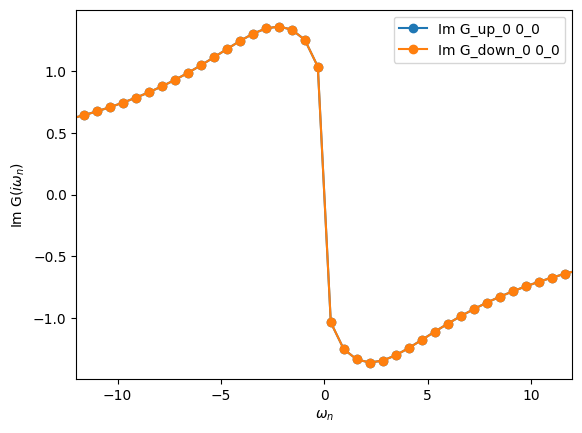

In [16]:
oplot(Delta_iw.imag, 'o-'); plt.xlim(-12, 12); plt.show()